In [1]:
!pip install gdown
!gdown --folder "https://drive.google.com/drive/folders/1ODtm94Wz1OXT6vNvO8UhcdBPYeE2VWzR" -O /kaggle/working/scarnet

Retrieving folder contents
Retrieving folder 1tvuVJaY0bH6UM-qBPAHvqmm8PFujuiTL Boxcar
Processing file 1PuNASx20C0fC2mIpJD7-6Kft4BrixY4F box (1).jpg
Processing file 1UKcM_NWhCc3pOOhLMkUk6rl59Anuid10 box (2).png
Processing file 1V0MY435eG8qd3k8WDIkfTv2fDHbn3TBo box (3).jpg
Processing file 1iwBmvsm-eol69WUP_u5s0R1fwRqzpu4L box (4).jpg
Processing file 1-X8jmQDAIf6pch8tmIuVnZYB3vQF6zVP box (5).png
Processing file 1j90mOPDNouNFYiIyAJTD75zyhGlirERo box (6).jpg
Processing file 1FoKc-B1nOaZoEXna-xpYgnAWM9tMRES7 box (7).jpg
Processing file 1DDdJ06uJrSfNmWtSC5ph_lwT9WSCwv7F Box (8).png
Processing file 11dPaHyfrCJRT5cmCoyUQYJ6CxvVQ0C4z box (9).jpg
Processing file 1_jDzqFO2PHbxtT-oG57RftKpr8XF_qr- box (10).jpg
Processing file 1pOZfR21rVLPVDhufzPR1U8kE-GFLgJhZ box (11).jpg
Processing file 1LLx61O_8RvwrYFJM9zCh-zuNFotlGqww box (12).jpg
Processing file 1WB2_SY1DdJKjL8ntBqpTPBWjMmTM9CUO Box (13).jpg
Processing file 1mv31n1fwyqDY8wipkviiynZuJGbCVZBZ box (14).jpg
Processing file 19s8UlGRFN8o071LxxnVXrgwH

In [2]:
import os
from collections import Counter

def summarize_folder(base_path, max_examples=5):
    print(f"\n{'='*60}")
    print(f"Summarizing: {base_path}")
    print('='*60)
    
    ext_counter = Counter()
    dir_count = 0
    file_count = 0
    examples = []
    
    for root, dirs, files in os.walk(base_path):
        dir_count += len(dirs)
        for f in files:
            file_count += 1
            ext = os.path.splitext(f)[1].lower()
            ext_counter[ext] += 1
            if len(examples) < max_examples:
                examples.append(os.path.join(root, f))
    
    print(f"Total directories: {dir_count}")
    print(f"Total files: {file_count}")
    print(f"\nFile types found:")
    for ext, count in ext_counter.most_common():
        print(f"  {ext if ext else '(no extension)'}: {count}")
    
    print(f"\nSample file paths:")
    for ex in examples:
        print(f"  {ex}")

summarize_folder('/kaggle/input/datasets/malgamage/scarnet')


Summarizing: /kaggle/input/datasets/malgamage/scarnet
Total directories: 6
Total files: 251

File types found:
  .jpg: 232
  .png: 14
  .jpeg: 4
  .jfif: 1

Sample file paths:
  /kaggle/input/datasets/malgamage/scarnet/Collected(ScarNet)/Hypertrophic/45.jpg
  /kaggle/input/datasets/malgamage/scarnet/Collected(ScarNet)/Hypertrophic/20.jpg
  /kaggle/input/datasets/malgamage/scarnet/Collected(ScarNet)/Hypertrophic/6.jpg
  /kaggle/input/datasets/malgamage/scarnet/Collected(ScarNet)/Hypertrophic/5.jpg
  /kaggle/input/datasets/malgamage/scarnet/Collected(ScarNet)/Hypertrophic/8.jpg


In [3]:
import os

scarnet_root = '/kaggle/input/datasets/malgamage/scarnet/Collected(ScarNet)'

for class_folder in sorted(os.listdir(scarnet_root)):
    class_path = os.path.join(scarnet_root, class_folder)
    if os.path.isdir(class_path):
        all_files = os.listdir(class_path)
        images = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif'))]
        non_images = [f for f in all_files if not f.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif'))]
        print(f"{class_folder}: {len(images)} images" + (f"  |  non-image files: {non_images}" if non_images else ""))

Boxcar: 50 images
Hypertrophic: 50 images
Ice Pick: 50 images
Keloid: 51 images
Rolling: 50 images


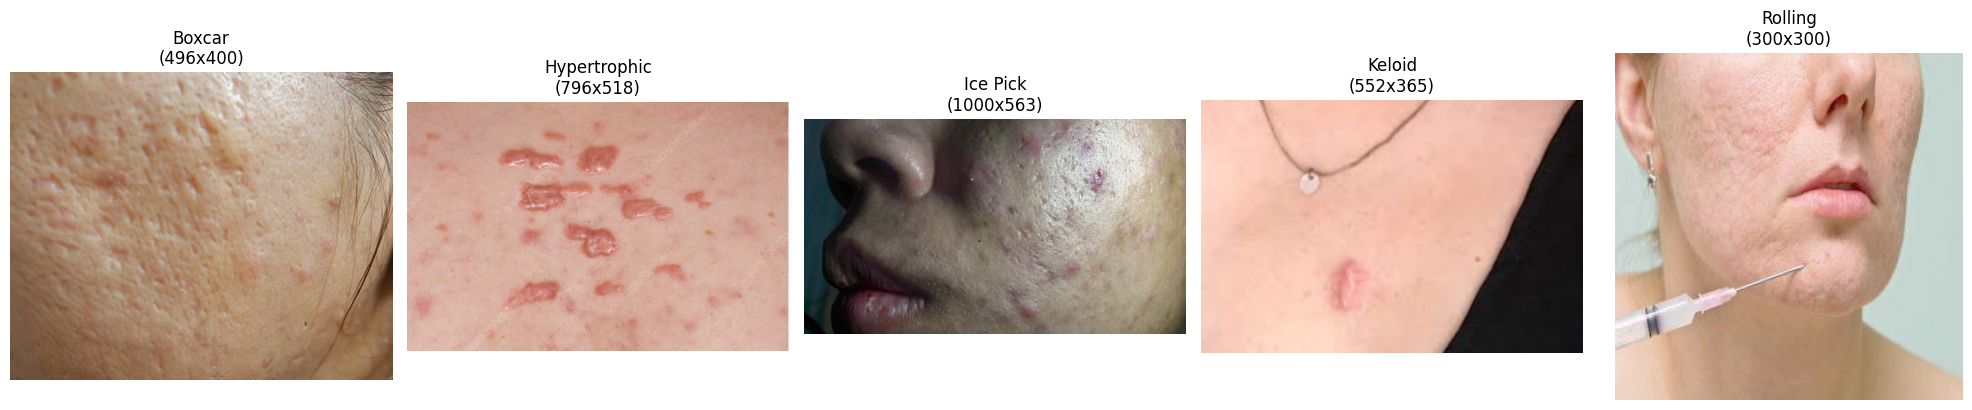

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

class_folders = sorted([d for d in os.listdir(scarnet_root) if os.path.isdir(os.path.join(scarnet_root, d))])

fig, axes = plt.subplots(1, len(class_folders), figsize=(4*len(class_folders), 4))
for ax, class_name in zip(axes, class_folders):
    class_path = os.path.join(scarnet_root, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif'))]
    if images:
        img = Image.open(os.path.join(class_path, images[0]))
        ax.imshow(img)
        ax.set_title(f"{class_name}\n({img.size[0]}x{img.size[1]})")
        ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
keloid_path = os.path.join(scarnet_root, 'Keloid')
for f in sorted(os.listdir(keloid_path)):
    print(f)

0.jpg
1.jpg
10.jpg
11.jpg
12.jpg
13.jpg
14.jpg
15.jpg
16.jpg
17.jpg
18.jpg
19.jpg
2.jpg
20.jpg
21.jpg
22.jpg
23.jpg
24.jpg
25.jpg
26.jpg
27.jpg
28.jpg
29.jpg
3.jpg
30.jpg
31.jpg
32.jpg
33.jpg
34.jpg
35.jpg
36.jpg
37.jpg
38.jpg
39.jpg
4.jpg
40.jpg
41.jpg
42.jpg
43.jpg
435.jpg
44.jpg
45.jpg
46.jpg
47.jpg
48.jpg
49.jpg
5.jpg
6.jpg
7.jpg
8.jpg
9.jpg


In [6]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os


class ScarNetDataset(Dataset):
    """
    Loads the ScarNet dataset: 5 scar classes (Boxcar, Hypertrophic, Ice Pick,
    Keloid, Rolling), each in its own subfolder under `root`.

    Verified: 251 images total (250 expected per original paper, 1 extra in
    Keloid class — see notebooks/02_scarnet_exploration.ipynb for investigation).
    """

    CLASSES = ['Boxcar', 'Hypertrophic', 'Ice Pick', 'Keloid', 'Rolling']

    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []  # list of (filepath, class_index)

        for class_idx, class_name in enumerate(self.CLASSES):
            class_path = os.path.join(root, class_name)
            if not os.path.isdir(class_path):
                continue
            for fname in os.listdir(class_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif')):
                    self.samples.append((os.path.join(class_path, fname), class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, class_idx = self.samples[idx]
        image = Image.open(filepath).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'label': class_idx,
            'class_name': self.CLASSES[class_idx],
            'filepath': filepath
        }


# Quick test
ds = ScarNetDataset(root=scarnet_root)
print(f"Dataset size: {len(ds)}")

sample = ds[0]
print(f"Class: {sample['class_name']} (label {sample['label']})")
print(f"Image size: {sample['image'].size}")
print(f"Filepath: {sample['filepath']}")

Dataset size: 251
Class: Boxcar (label 0)
Image size: (496, 400)
Filepath: /kaggle/input/datasets/malgamage/scarnet/Collected(ScarNet)/Boxcar/box (47).jpg


Size: (1296, 728)


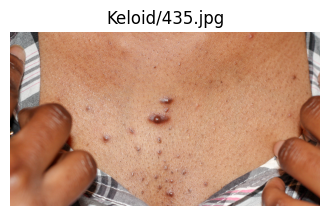

In [7]:
from PIL import Image
img = Image.open(os.path.join(keloid_path, '435.jpg'))
print("Size:", img.size)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title('Keloid/435.jpg')
plt.axis('off')
plt.show()